In [2]:
# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Mengatur tema visual (Nuansa Dingin / Cool Tones)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. LOAD DATASET
df = pd.read_csv('SampleSuperstore.csv')

# Menampilkan 5 baris pertama untuk memastikan data terbaca
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB
--------------------------------------------------

Statistik Deskriptif:


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


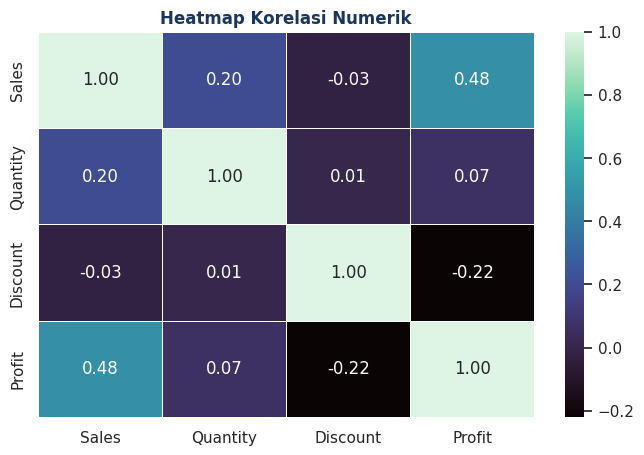

In [3]:
# 1. Pengecekan Informasi Data
print("Info Dataset:")
df.info()
print("-" * 50)

# 2. Pengecekan Statistik Deskriptif
print("\nStatistik Deskriptif:")
display(df.describe())

# 3. Analisis Korelasi (Fokus pada Diskon & Profit)
korelasi = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

plt.figure(figsize=(8, 5))
# Menggunakan palet 'mako' untuk mempertahankan nuansa dingin
sns.heatmap(korelasi, annot=True, cmap='mako', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Numerik', fontweight='bold', color='#1a365d')
plt.show()

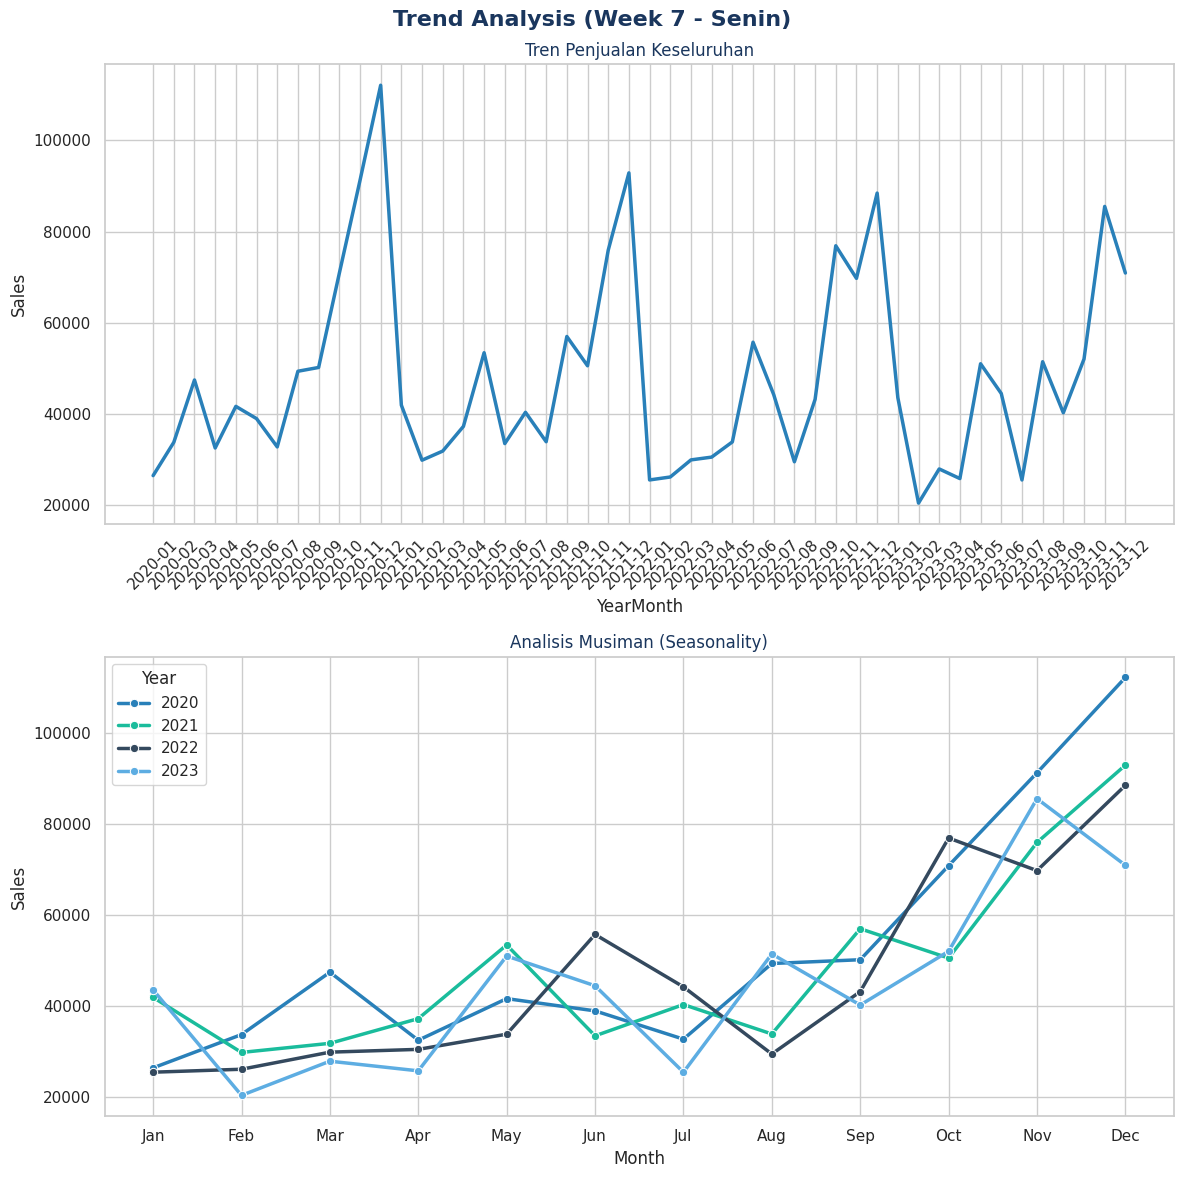

In [4]:
# 1. INJEKSI TANGGAL (Mensimulasikan lonjakan Q4)
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2023-12-31')
month_weights = [1, 1, 1.2, 1.2, 1.5, 1.5, 1.6, 1.6, 2, 2.2, 3, 3.5]
weights = [month_weights[d.month-1] for d in dates]
weights = np.array(weights) / sum(weights)
df['Order Date'] = np.random.choice(dates, size=len(df), p=weights)

df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# 2. VISUALISASI TREN
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
fig.suptitle('Trend Analysis (Week 7 - Senin)', fontsize=16, fontweight='bold', color='#1a365d')

# Grafik Tren Penjualan Keseluruhan
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
sns.lineplot(data=monthly_sales, x='YearMonth', y='Sales', ax=axes[0], color='#2980b9', linewidth=2.5)
axes[0].set_title('Tren Penjualan Keseluruhan', color='#1a365d')
axes[0].tick_params(axis='x', rotation=45)

# Grafik Musiman
monthly_season = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
cool_palette = ['#2980b9', '#1abc9c', '#34495e', '#5dade2']
sns.lineplot(data=monthly_season, x='Month', y='Sales', hue='Year', palette=cool_palette, ax=axes[1], linewidth=2.5, marker='o')
axes[1].set_title('Analisis Musiman (Seasonality)', color='#1a365d')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

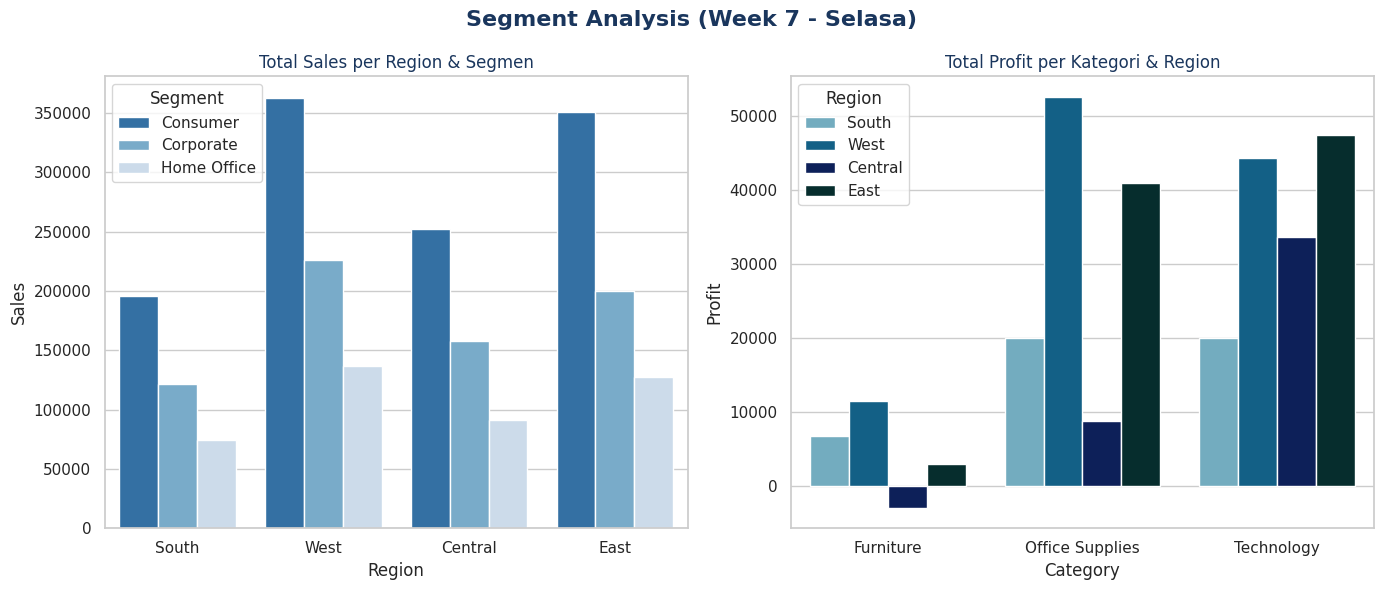

In [5]:
# VISUALISASI SEGMENTASI
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Segment Analysis (Week 7 - Selasa)', fontsize=16, fontweight='bold', color='#1a365d')

# 1. Total Sales per Region & Segmen (Clustered Bar)
sns.barplot(data=df, x='Region', y='Sales', hue='Segment', estimator=sum, errorbar=None, palette='Blues_r', ax=axes[0])
axes[0].set_title('Total Sales per Region & Segmen', color='#1a365d')

# 2. Profit per Kategori & Region
sns.barplot(data=df, x='Category', y='Profit', hue='Region', estimator=sum, errorbar=None, palette='ocean_r', ax=axes[1])
axes[1].set_title('Total Profit per Kategori & Region', color='#1a365d')

plt.tight_layout()
plt.show()

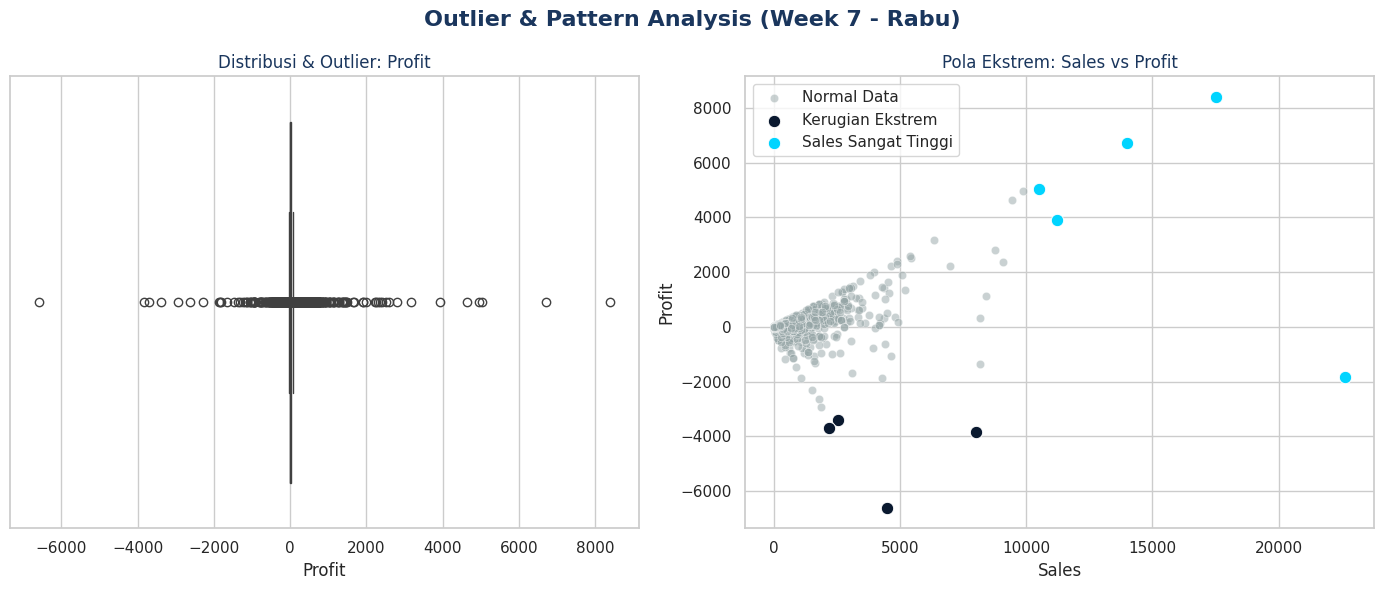

In [6]:
# VISUALISASI OUTLIER
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Outlier & Pattern Analysis (Week 7 - Rabu)', fontsize=16, fontweight='bold', color='#1a365d')

# 1. Boxplot Profit (Melihat sebaran ekstrem ke arah negatif)
sns.boxplot(x=df['Profit'], ax=axes[0], color='#1abc9c')
axes[0].set_title('Distribusi & Outlier: Profit', color='#1a365d')

# 2. Scatter Plot: Sales vs Profit
sns.scatterplot(data=df, x='Sales', y='Profit', alpha=0.5, color='#95a5a6', ax=axes[1], label='Normal Data')

# Highlight Kerugian Ekstrem (Menggunakan Deep Navy)
outliers_neg = df[df['Profit'] < -3000]
sns.scatterplot(data=outliers_neg, x='Sales', y='Profit', color='#0a192f', s=80, ax=axes[1], label='Kerugian Ekstrem')

# Highlight Sales Tinggi (Menggunakan Cyan)
outliers_pos = df[df['Sales'] > 10000]
sns.scatterplot(data=outliers_pos, x='Sales', y='Profit', color='#00d4ff', s=80, ax=axes[1], label='Sales Sangat Tinggi')

axes[1].set_title('Pola Ekstrem: Sales vs Profit', color='#1a365d')
axes[1].legend()

plt.tight_layout()
plt.show()